AI-BASED NATURAL DISASTER RISK PREDICTION AND EARLY WARNING SYSTEM                             
Starting off with FLOOD.                                                                       
Second Stage: MODEL TRAINING TO TRAIN RandomForest and XGBoost MODELS.


In [1]:
#Step1: Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import joblib
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
#Step2: Loading the Dataset
DATA_FILE = r'C:/Nepal_Flood_Project/Data/final_flood_dataset_ml_ready.csv'
df = pd.read_csv(DATA_FILE)
print(f'Dataset loaded!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nFirst 3 rows:')
print(df.head(3))
print(f'\nLabel distribution:')
print(df['flood_risk_label'].value_counts().rename({0:'Low', 1:'Medium', 2:'High'}))

Dataset loaded!
Shape: 66479 rows x 13 columns

Columns: ['temperature', 'rainfall', 'humidity', 'wind_speed', 'discharge', 'rainfall_roll3', 'rainfall_roll7', 'discharge_roll3', 'discharge_roll7', 'month', 'season_encoded', 'location_encoded', 'flood_risk_label']

First 3 rows:
   temperature  rainfall  humidity  wind_speed  discharge  rainfall_roll3  \
0        17.16       0.0     32.01        0.98      479.0             0.0   
1        16.94       0.0     33.37        1.20      473.0             0.0   
2        16.42       0.0     32.56        1.17      469.0             0.0   

   rainfall_roll7  discharge_roll3  discharge_roll7  month  season_encoded  \
0             0.0       479.000000       479.000000      1               3   
1             0.0       476.000000       476.000000      1               3   
2             0.0       473.666667       473.666667      1               3   

   location_encoded  flood_risk_label  
0                 0                 0  
1                 

In [3]:
#Step3: Separating Features and Label

X = df.drop(columns=['flood_risk_label'])
y = df['flood_risk_label']
print(f'Features and label separated!')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nFeature columns: {X.columns.tolist()}')

Features and label separated!
X shape: (66479, 12)
y shape: (66479,)

Feature columns: ['temperature', 'rainfall', 'humidity', 'wind_speed', 'discharge', 'rainfall_roll3', 'rainfall_roll7', 'discharge_roll3', 'discharge_roll7', 'month', 'season_encoded', 'location_encoded']


In [4]:
#Step4: Splitting into Training and Testing Sets 


df_full = pd.read_csv('C:/Nepal_Flood_Project/Data/final_flood_dataset.csv')
df_full['date'] = pd.to_datetime(df_full['date'])

feature_cols = [
    'temperature', 'rainfall', 'humidity', 'wind_speed',
    'discharge', 'rainfall_roll3', 'rainfall_roll7',
    'discharge_roll3', 'discharge_roll7',
    'month', 'location_encoded'
]

train_data = df_full[df_full['date'].dt.year <= 2020]
test_data  = df_full[df_full['date'].dt.year >= 2021]

X_train = train_data[feature_cols]
y_train = train_data['flood_risk_label']
X_test  = test_data[feature_cols]
y_test  = test_data['flood_risk_label']

print('Temporal split complete!')
print(f'Training: 2000-2020 -> {len(X_train)} rows')
print(f'Testing:  2021-2025 -> {len(X_test)} rows')
print(f'\nTraining label distribution:')
print(y_train.value_counts().rename({0:"Low", 1:"Medium", 2:"High"}))
print(f'\nTesting label distribution:')
print(y_test.value_counts().rename({0:"Low", 1:"Medium", 2:"High"}))

Temporal split complete!
Training: 2000-2020 -> 53697 rows
Testing:  2021-2025 -> 12782 rows

Training label distribution:
flood_risk_label
Low       51580
Medium     1932
High        185
Name: count, dtype: int64

Testing label distribution:
flood_risk_label
Low       12226
Medium      531
High         25
Name: count, dtype: int64


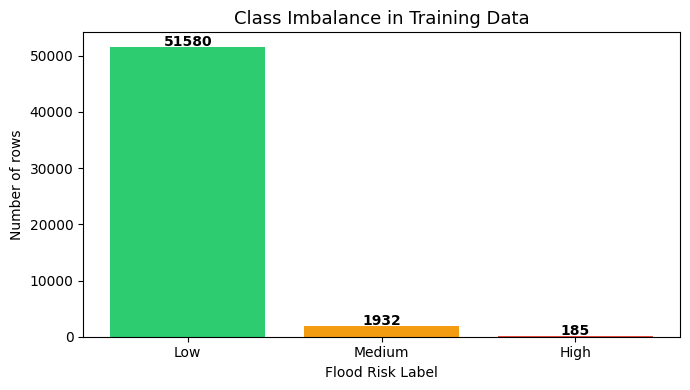

Class imbalance visualized!


In [5]:
#Step5: Handling Class Imbalance

label_names = {0: 'Low', 1: 'Medium', 2: 'High'}
counts = y_train.value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
plt.figure(figsize=(7, 4))
plt.bar([label_names[i] for i in counts.index], counts.values, color=colors)
plt.title('Class Imbalance in Training Data', fontsize=13)
plt.ylabel('Number of rows')
plt.xlabel('Flood Risk Label')
for i, v in enumerate(counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150)
plt.show()
print('Class imbalance visualized!')

In [6]:
#Step6: Training the Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f'Random Forest training complete!')
print(f'Accuracy on test data: {rf_accuracy*100:.2f}%')

Random Forest training complete!
Accuracy on test data: 91.61%


In [7]:
# Step 7: Training XGBoost Model (with SMOTE to handle class imbalance)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', pd.Series(y_train_sm).value_counts().to_dict())

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)
xgb_model.fit(X_train_sm, y_train_sm)

HIGH_RISK_THRESHOLD = 0.01
probs = xgb_model.predict_proba(X_test)
xgb_predictions = np.where(
    probs[:, 2] > HIGH_RISK_THRESHOLD, 2,
    np.argmax(probs[:, :2], axis=1)
)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print(f'\nXGBoost (SMOTE + threshold={HIGH_RISK_THRESHOLD}) training complete!')
print(f'Accuracy on test data: {xgb_accuracy*100:.2f}%')

Before SMOTE: {0: 51580, 1: 1932, 2: 185}
After SMOTE: {0: 51580, 1: 51580, 2: 51580}

XGBoost (SMOTE + threshold=0.01) training complete!
Accuracy on test data: 84.77%


RANDOM FOREST - Detailed Evaluation
              precision    recall  f1-score   support

         Low       0.97      0.95      0.96     12226
      Medium       0.18      0.27      0.22       531
        High       0.00      0.00      0.00        25

    accuracy                           0.92     12782
   macro avg       0.38      0.41      0.39     12782
weighted avg       0.93      0.92      0.92     12782

XGBOOST - Detailed Evaluation
              precision    recall  f1-score   support

         Low       0.98      0.87      0.92     12226
      Medium       0.22      0.44      0.29       531
        High       0.02      0.60      0.03        25

    accuracy                           0.85     12782
   macro avg       0.40      0.64      0.42     12782
weighted avg       0.94      0.85      0.89     12782



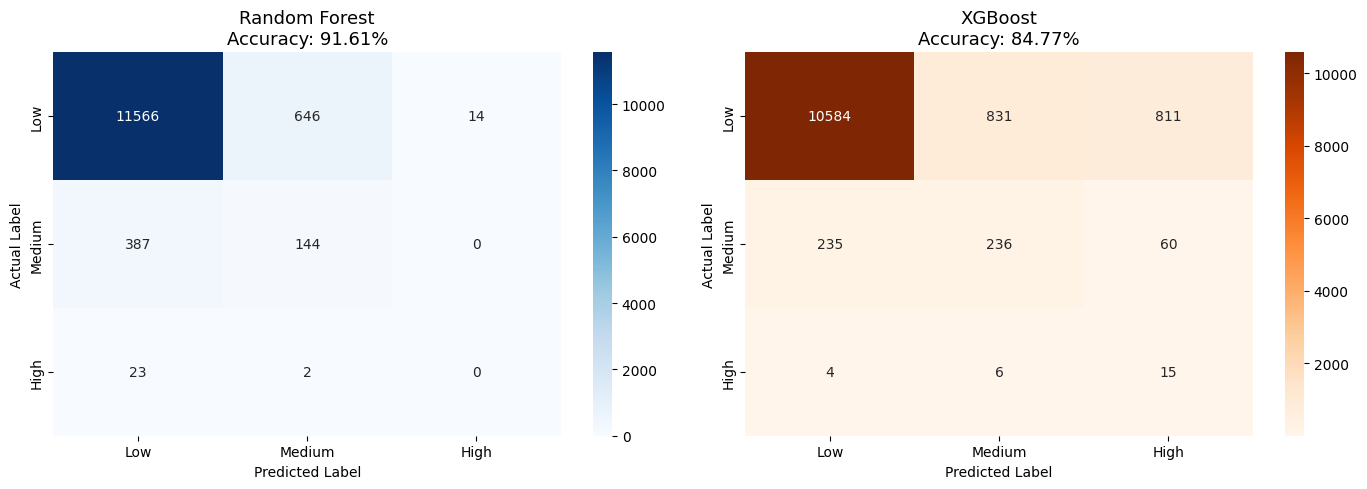

Confusion matrices saved!


In [8]:
#Step8: Evaluating Both Models
label_names = ['Low', 'Medium', 'High']
print('=' * 60)
print('RANDOM FOREST - Detailed Evaluation')
print('=' * 60)
print(classification_report(y_test, rf_predictions, target_names=label_names))

print('=' * 60)
print('XGBOOST - Detailed Evaluation')
print('=' * 60)
print(classification_report(y_test, xgb_predictions, target_names=label_names))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rf_cm = confusion_matrix(y_test, rf_predictions)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title(f'Random Forest\nAccuracy: {rf_accuracy*100:.2f}%', fontsize=13)
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

xgb_cm = confusion_matrix(y_test, xgb_predictions)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title(f'XGBoost\nAccuracy: {xgb_accuracy*100:.2f}%', fontsize=13)
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print('Confusion matrices saved!')

In [9]:
#Step9: Comparing Both Models
from sklearn.metrics import f1_score, recall_score, precision_score

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Overall Accuracy': [
        round(rf_accuracy * 100, 2),
        round(xgb_accuracy * 100, 2)
    ],
    'High Risk Recall (%)': [
        round(recall_score(y_test, rf_predictions, average=None)[2] * 100, 2),
        round(recall_score(y_test, xgb_predictions, average=None)[2] * 100, 2)
    ],
    'High Risk Precision (%)': [
        round(precision_score(y_test, rf_predictions, average=None, zero_division=0)[2] * 100, 2),
        round(precision_score(y_test, xgb_predictions, average=None, zero_division=0)[2] * 100, 2)
    ],
    'Macro F1 Score': [
        round(f1_score(y_test, rf_predictions, average='macro') * 100, 2),
        round(f1_score(y_test, xgb_predictions, average='macro') * 100, 2)
    ]
})
print('=' * 65)
print('MODEL COMPARISON RESULTS')
print('=' * 65)
print(results.to_string(index=False))
print('=' * 65)
best_idx = results['High Risk Recall (%)'].idxmax()
print(f'\nBest model based on High Risk Recall: {results.loc[best_idx, "Model"]}')

MODEL COMPARISON RESULTS
        Model  Overall Accuracy  High Risk Recall (%)  High Risk Precision (%)  Macro F1 Score
Random Forest             91.61                   0.0                     0.00           39.12
      XGBoost             84.77                  60.0                     1.69           41.52

Best model based on High Risk Recall: XGBoost


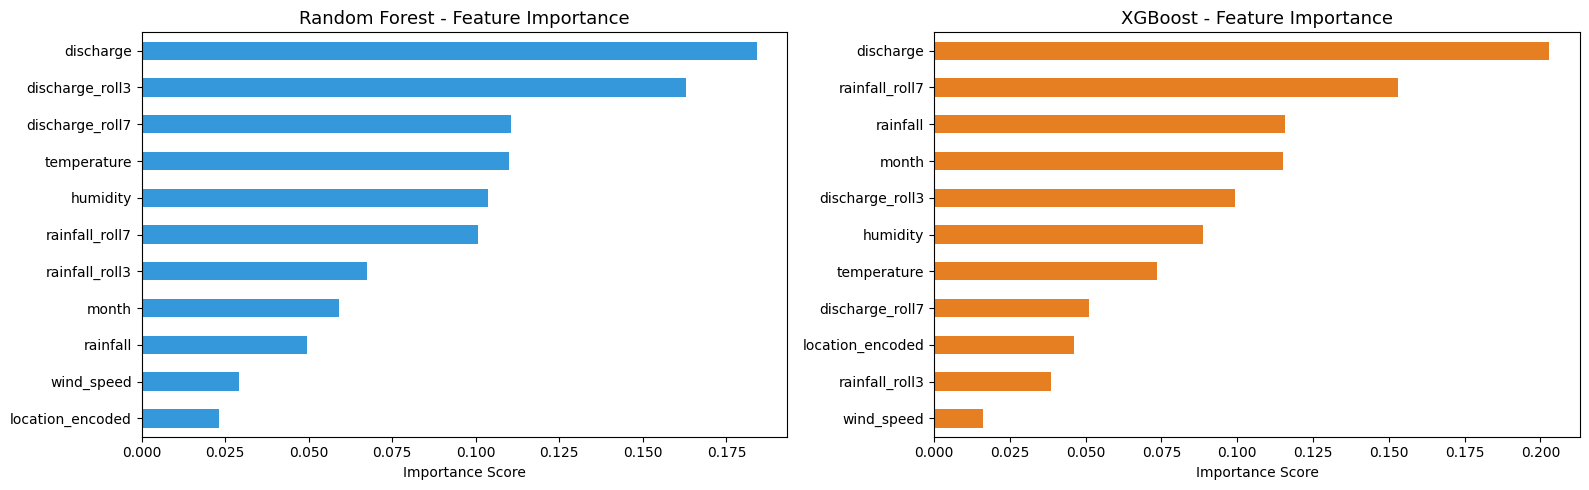

Feature importance charts saved!


In [10]:
#Step10: Feature Importance

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols)
rf_importance.sort_values().plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Random Forest - Feature Importance', fontsize=13)
axes[0].set_xlabel('Importance Score')

xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols)
xgb_importance.sort_values().plot(kind='barh', ax=axes[1], color='#e67e22')
axes[1].set_title('XGBoost - Feature Importance', fontsize=13)
axes[1].set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Feature importance charts saved!')

In [11]:
#Step11: Saving the best Model

joblib.dump(rf_model, 'flood_random_forest_model.pkl')
joblib.dump(xgb_model, 'flood_xgboost_model.pkl')
joblib.dump(HIGH_RISK_THRESHOLD, 'flood_xgboost_threshold.pkl')
print('Models saved!')
print('   flood_random_forest_model.pkl')
print('   flood_xgboost_model.pkl')
print('   flood_xgboost_threshold.pkl')

Models saved!
   flood_random_forest_model.pkl
   flood_xgboost_model.pkl
   flood_xgboost_threshold.pkl


In [12]:
# Step 12: Testing the model with sample predictions
label_map = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}

test_scenarios = [
    [12.0,  0.0, 55.0, 1.5,   15.0,   0.0,   0.0,   15.0,   15.0, 1, 3],
    [24.0, 25.0, 88.0, 2.8,   99.0,  60.0, 140.0,  110.0,  105.0, 7, 6],
    [30.0, 65.0, 95.0, 4.2, 1700.0, 180.0, 400.0, 1900.0, 1800.0, 8, 0],
]
scenario_names = [
    'Dry Winter Day (Kathmandu, January)',
    'Moderate Monsoon Day (Pokhara, July)',
    'Heavy Monsoon Day (Biratnagar, August)'
]

print('Testing model with sample scenarios:')
print('=' * 65)
for name, values in zip(scenario_names, test_scenarios):
    input_data = pd.DataFrame([values], columns=feature_cols)
    rf_pred = rf_model.predict(input_data)[0]
    xgb_prob = xgb_model.predict_proba(input_data)[0]
    xgb_pred = 2 if xgb_prob[2] > HIGH_RISK_THRESHOLD else np.argmax(xgb_prob[:2])
    print(f'\nScenario: {name}')
    print(f'  Random Forest -> {label_map[rf_pred]}')
    print(f'  XGBoost       -> {label_map[xgb_pred]} (High prob: {xgb_prob[2]:.3f})')
print('\n' + '=' * 65)
print('Sample predictions complete!')

Testing model with sample scenarios:

Scenario: Dry Winter Day (Kathmandu, January)
  Random Forest -> Low Risk
  XGBoost       -> Low Risk (High prob: 0.000)

Scenario: Moderate Monsoon Day (Pokhara, July)
  Random Forest -> Medium Risk
  XGBoost       -> Medium Risk (High prob: 0.000)

Scenario: Heavy Monsoon Day (Biratnagar, August)
  Random Forest -> Low Risk
  XGBoost       -> High Risk (High prob: 0.021)

Sample predictions complete!
